In [10]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

Import the CSV Data as Pandas DataFrame


In [11]:
df = pd.read_csv('data\StudentsPerformance.csv')

Show Top 5 Records

In [12]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Preparing X and Y variables

In [13]:
X = df.drop(columns='math score',axis=1)


In [14]:
X.shape

(1000, 7)

In [15]:
Y = df['math score']

In [16]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [17]:
X = preprocessor.fit_transform(X)

In [18]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [19]:
X.shape

(1000, 19)

Split dataset for training and testing

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=21)

In [26]:
print(X.shape , X_train.shape , X_test.shape)

(1000, 19) (800, 19) (200, 19)


Create an Evaluate Function to give all metrics after model Training

In [27]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):

    model = list(models.values())[i]
    model.fit(X_train,Y_train)

    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(Y_train, Y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(Y_test, Y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print("\n")


Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.2628
- Mean Absolute Error: 4.1877
- R2 Score: 0.8808
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.5991
- Mean Absolute Error: 4.4962
- R2 Score: 0.8561


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5244
- Mean Absolute Error: 5.1385
- R2 Score: 0.8169
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.4524
- Mean Absolute Error: 5.1328
- R2 Score: 0.8089


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.2566
- Mean Absolute Error: 4.1873
- R2 Score: 0.8811
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.6070
- Mean Absolute Error: 4.4947
- R2 Score: 0.8557


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7785
- Mean Absolute Error: 4.6158
- R2 Score: 0.8563
-----------------------

Results

In [29]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
0,Linear Regression,0.856128
2,Ridge,0.855721
7,CatBoosting Regressor,0.832755
5,Random Forest Regressor,0.826478
1,Lasso,0.808932
8,AdaBoost Regressor,0.807989
6,XGBRegressor,0.793972
3,K-Neighbors Regressor,0.754153
4,Decision Tree,0.645276


Linear Regression

In [30]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,Y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(Y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 85.61


Plot y_pred and y_test

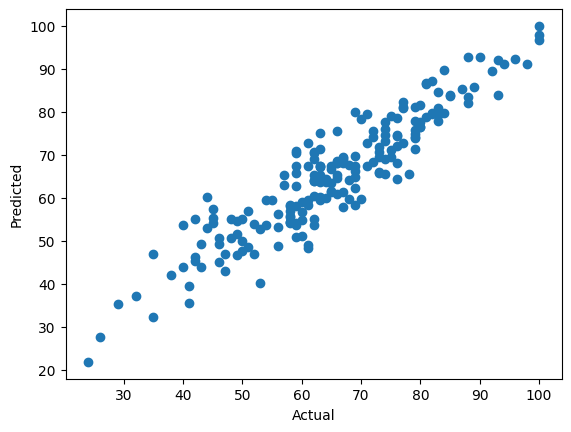

In [31]:
plt.scatter(Y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

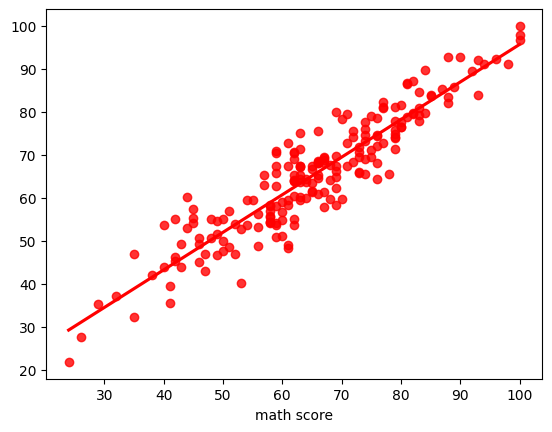

In [32]:
sns.regplot(x=Y_test,y=y_pred,ci=None,color ='red');

Difference between Actual and Predicted Values

In [34]:
pred_df=pd.DataFrame({'Actual Value':Y_test,'Predicted Value':y_pred,'Difference':Y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
492,83,80.90625,2.09375
383,38,42.00000,-4.00000
856,75,69.37500,5.62500
834,58,54.03125,3.96875
603,60,56.59375,3.40625
...,...,...,...
72,41,39.46875,1.53125
400,59,54.06250,4.93750
813,87,85.28125,1.71875
195,61,59.37500,1.62500
